In [180]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

In [181]:
df_1 = pd.read_csv("../../data/crime/Stop_Data_2019_to_2022.csv",low_memory=False) ##https://opendata.dc.gov/datasets/1d0cbb1658d54027a54234f6b9bf52bf_45/explore
df_2 = pd.read_csv("../../data/crime/Stop_Data.csv",low_memory=False) ##https://opendata.dc.gov/datasets/5c359f8ebdf24d22a1f840d64c5cc540_41/explore

df = pd.concat([df_1,df_2])

## historic stop data 

historic_stops = pd.read_csv("../../data/crime/Stop_Incidents_2010_to_2017.csv")

## Filtering data to Non-ticket Stops

Previously, MPD released a dataset of just "stop encounters." However, in the most recent dataset, MPD has decided to combine additional interactions, such as routine traffic stops, in this dataset. As a result, the data has fundamentally changed from the previous dataset. In an effort to examine interactions that may be viewed as "stop and frisk," we'll start by examining the intereasctions that didn't result in a ticket (but may have resulted in an arrest) to filter out some of the noise. 

In [188]:
non_ticket_df = df[df['STOP_TYPE'] == "Non-ticket Stop"]

all_reasons = []

## getting clean, unique list of all stop reasons

for reasons in non_ticket_df['STOP_REASON_NONTICKET'].unique():
    if str(reasons) != 'nan':
        reasons = reasons.replace(';',',')
        reasons_list = reasons.split(',')

        for item in reasons_list:
            ## dealing with some accidental duplicates in original data
            if ('Individual' in item and 'character' in item):            
                non_ticket_df.loc[non_ticket_df['STOP_REASON_NONTICKET'] == item,"STOP_REASON_NONTICKET"] = "Individual's characteristics"
                item = "Individual's characteristics"

            elif ('Individual' in item and 'actions' in item):
                non_ticket_df.loc[non_ticket_df['STOP_REASON_NONTICKET'] == item,"STOP_REASON_NONTICKET"] = "Individual's actions"
                item = "Individual's actions"

            if item.strip() not in all_reasons:
                all_reasons.append(item.strip())

Thankfully, MPD provides a reason for the non-ticket stop in the data. This helps us add a context to the interaction. We can see that some of these are not necessarily "stop and frisk," such as responding to a crash or responding to a BOLO/Lookout. For the following analysis, we'll focus on the following subset of data that more or lkess indicates officer discretion in making a stop not directly tied to a call for service:

- Individual's actions
- Individual's characteristics
- Suspicion of criminal activity (self-initiated)

Please not that single stops can be assigned multiple reasons, so we'll start by including all stops that included the reasons above, but may also have other reasons assigned.

In [189]:
for reason in all_reasons:
    sub_df = non_ticket_df[non_ticket_df['STOP_REASON_NONTICKET'].str.contains(reason,regex=False,na=False)]

    eth_df = sub_df['ETHNICITY'].value_counts(normalize=True).reset_index()
    eth_df_counts = sub_df['ETHNICITY'].value_counts().reset_index()

    try:
        print("{} | {} | {}".format(reason, 
                            round(eth_df[eth_df['ETHNICITY'] == 'Black']['proportion'].iloc[0],2),
                            eth_df_counts[eth_df_counts['ETHNICITY'] == 'Black']['count'].iloc[0]))
    except Exception as e:
        continue

Call for service | 0.84 | 66666
Observed a weapon | 0.91 | 1974
Individual's actions | 0.85 | 16752
Traffic violation | 0.86 | 12156
BOLO/Lookout | 0.88 | 18157
Information obtained from witnesses or informants | 0.83 | 7344
Suspicion of criminal activity (self-initiated) | 0.88 | 13949
Warrant/court order | 0.91 | 14450
Individual's characteristics | 0.91 | 2308
Prior knowledge | 0.9 | 4675
Response to crash | 0.79 | 949
Information obtained from law enforcement sources | 0.89 | 9521
Demeanor during a field contact | 0.88 | 4138
Truancy Stop | 1.0 | 1
Medical/Behavioral Health Event | 0.82 | 198
Curfew | 0.86 | 244
Truancy | 0.71 | 1329


In [190]:
non_ticket_vis = non_ticket_df[(non_ticket_df['STOP_REASON_NONTICKET'].str.contains("Individual's",na=False)) | 
                               (non_ticket_df['STOP_REASON_NONTICKET'] == "Suspicion of criminal activity (self-initiated)")]

## potential filter: removing all stops that have a stop based on individual's characteristics AND other reasons, like traffic violations

for item in ["Individual's actions","Individual's characteristics","Suspicion of criminal activity (self-initiated)"]:
    all_reasons.remove(item)

for item in all_reasons:
    non_ticket_vis = non_ticket_vis[~non_ticket_vis['STOP_REASON_NONTICKET'].str.contains(item)]

non_ticket_vis = non_ticket_vis[~non_ticket_vis['STOP_REASON_NONTICKET'].str.contains('Call for service')]
non_ticket_vis = non_ticket_vis[~non_ticket_vis['STOP_REASON_NONTICKET'].str.contains('BOLO')]

non_ticket_vis['STOP_REASON_NONTICKET'].value_counts()

STOP_REASON_NONTICKET
Individual's actions                                                                                   18534
Suspicion of criminal activity (self-initiated)                                                         7660
Individual's characteristics                                                                            1912
Individual's actions, Suspicion of criminal activity (self-initiated)                                    188
Individual's actions, Individual's characteristics                                                       185
Individual's actions, Individual's characteristics, Suspicion of criminal activity (self-initiated)      115
Individual's characteristics, Suspicion of criminal activity (self-initiated)                             24
Name: count, dtype: int64

In [191]:
summary_df = non_ticket_vis.groupby(['ETHNICITY'])['PERSON_SEARCH_PAT_DOWN'].value_counts(normalize=True).reset_index()

summary_df[summary_df['ETHNICITY'].isin(['White','Black','Hispanic/Latino'])]

,ETHNICITY,PERSON_SEARCH_PAT_DOWN,proportion
4,Black,0,0.697602
5,Black,1,0.302398
8,Hispanic/Latino,0,0.892683
9,Hispanic/Latino,1,0.107317
18,White,0,0.869326
19,White,1,0.130674


In [73]:
non_ticket_vis['pat_simple'] = non_ticket_vis['PERSON_PAT_DOWN_REASON'].str.replace(';.*','',regex=True)

for race in ['White','Black','Hispanic/Latino']:
    race_df = non_ticket_vis[non_ticket_vis['ETHNICITY'] == race]

    #display(race_df.groupby(['ETHNICITY'])['pat_simple'].value_counts(normalize=True).reset_index())

C:\Users\august.warren\AppData\Local\Temp\ipykernel_22152\3482667852.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_ticket_vis['pat_simple'] = non_ticket_vis['PERSON_PAT_DOWN_REASON'].str.replace(';.*','',regex=True)


In [193]:
## not as clear of a difference among those charged/not charged by race. Would be nice to see % no papered...

non_ticket_vis['charged'] = np.where(non_ticket_vis['ARREST_CHARGES'].isna(),'No charges','Charged')

non_ticket_vis[non_ticket_vis['ETHNICITY'].isin(['White','Black','Hispanic/Latino'])].groupby('ETHNICITY')['charged'].value_counts(normalize=True,dropna=False)

ETHNICITY        charged   
Black            No charges    0.570565
                 Charged       0.429435
Hispanic/Latino  Charged       0.518293
                 No charges    0.481707
White            No charges    0.547455
                 Charged       0.452545
Name: proportion, dtype: float64

## Comparing Historical/Previous Stop & Frisk to Our New Stop Universe

Some weird spikes in non-ticketed stops at the start and end of the time window, which aren't really explained by any jumps in violent crimes. However, the non-ticketed stops in the time period between these spikes are consistend with the previous stop data MPD previously published. 

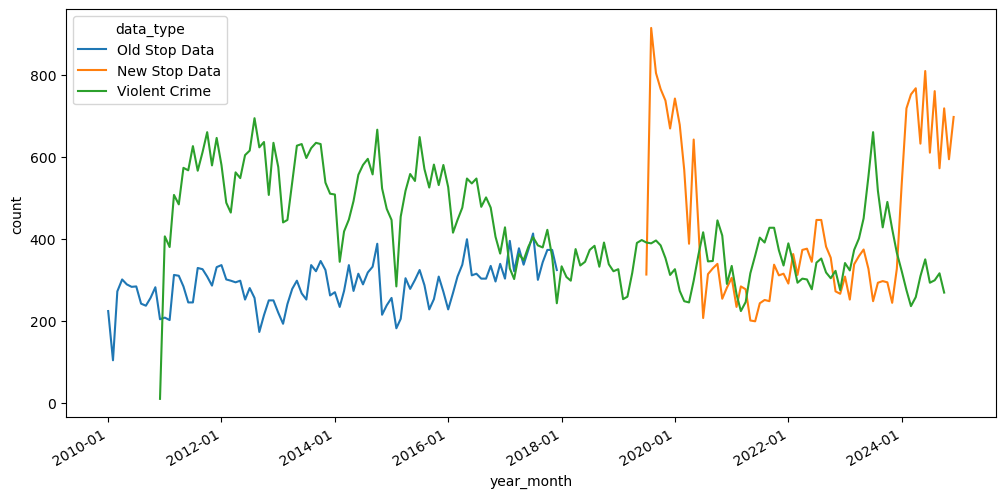

In [195]:
## loading crime data into the plot from context

crime_df = pd.DataFrame()

for file in os.listdir("../../data/crime/crime_incidents_2007_2024"):
    if file not in ['__MACOSX','2007_2008_crime_data.txt','2009_2010_crime_data.txt']:
        df = pd.read_csv("../../data/crime/crime_incidents_2007_2024/{}".format(file))

        date_formats =["%m/%d/%Y %H:%M:%S %p","%Y-%m-%dT%H:%M:%S","%Y/%m/%d %H:%M:%S","%Y-%m-%dT%H:%M:%S.000Z","%Y/%m/%d %H:%M:%S+00"] 
        date_error = True

        for date in date_formats:
            try:
                df.loc[:,'year_month'] = pd.to_datetime(df['REPORT_DAT'],format=date).dt.strftime("%Y-%m")
                date_error = False

            except Exception as e:
                date_error = True

        crime_df = pd.concat([crime_df,df])

crime_df.loc[crime_df['OFFENSE'].isin(['HOMICIDE','SEX ABUSE','ASSAULT W/DANGEROUS WEAPON','ROBBERY']),'violent_crime'] = 1

crime_df_agg = crime_df.groupby('year_month')['violent_crime'].sum().reset_index().rename(columns={'violent_crime': 'count'})
crime_df_agg['data_type'] = 'Violent Crime'

new_data_counts = pd.to_datetime(non_ticket_vis['DATETIME']).dt.strftime("%Y-%m").value_counts().reset_index().rename(columns={'DATETIME': 'year_month'})
new_data_counts['data_type'] = 'New Stop Data'

old_data_counts = pd.to_datetime(historic_stops['REPORT_TAKEN_DATE_EST']).dt.strftime("%Y-%m").value_counts().reset_index().rename(columns={'REPORT_TAKEN_DATE_EST': 'year_month'})
old_data_counts['data_type'] = 'Old Stop Data'

old_data_counts = old_data_counts[pd.to_datetime(old_data_counts['year_month'],format='%Y-%m') < pd.to_datetime('2018-01-01')]

data_counts = pd.concat([old_data_counts,new_data_counts,crime_df_agg])

data_counts['year_month'] = pd.to_datetime(data_counts['year_month'])

## plotting trends

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data_counts,x='year_month',y='count',hue='data_type',ax=ax)

date_form = mdates.DateFormatter('%Y-%m')
ax.xaxis.set_major_formatter(date_form)
fig.autofmt_xdate()
plt.show()